In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report,confusion_matrix

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

from spacy.lang.en.stop_words import STOP_WORDS as en_stop



# Processing data

In [9]:
# Variable
percentage_genre_to_keep = 25
test_size = 0.2
random_state = 42

In [8]:
df = pd.read_csv("../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['Script','filtered_genre']

df_filtered_one_genre_to_train = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_filtered_one_genre_to_train = df_filtered_one_genre_to_train[columns_to_keep].reset_index(drop=True)


C:\Users\letru\AppData\Local\Temp\ipykernel_13204\2139164612.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


# Augmentation data

# Training and test

In [11]:
X_train,X_test , y_train,y_test = train_test_split(df_filtered_one_genre_to_train['Script'],df_filtered_one_genre_to_train['filtered_genre'],test_size=test_size,random_state=random_state)

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

d:\programmation\nlp\.venv\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.52      0.66      0.58       314
imdb_documentary       0.89      0.80      0.84       251
      imdb_drama       0.66      0.73      0.69       609
     imdb_horror       0.62      0.56      0.59       171
    imdb_romance       0.84      0.26      0.40        61
   imdb_thriller       0.67      0.36      0.47       138

        accuracy                           0.65      1544
       macro avg       0.70      0.56      0.59      1544
    weighted avg       0.67      0.65      0.65      1544



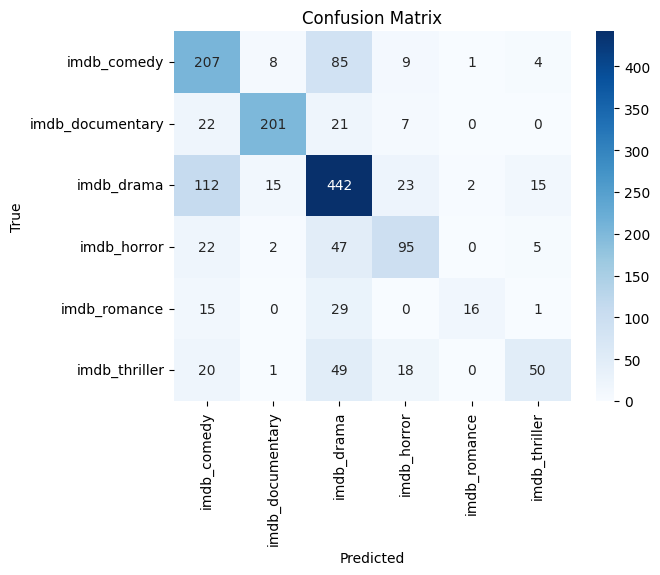

In [15]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1), stop_words = list(en_stop)), MultinomialNB())
model.fit(X_train, y_train_encoded)
y_pred = model.predict(X_test)
print(f"Classification Report:\n", classification_report(y_test, encoder.inverse_transform(y_pred)))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [16]:
# Perform augmentation